# Explore Programming Languages

This notebook explores the programming languages in the AIDev dataset to identify the 3 most popular languages for our library usage analysis.

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

data_dir = Path("../data")

In [2]:
# Load the repository data
repo_pop_df = pd.read_parquet(data_dir / "repository.parquet")
pr_pop_df = pd.read_parquet(data_dir / "pull_request.parquet")

print(f"Repositories: {len(repo_pop_df):,}")
print(f"Pull Requests: {len(pr_pop_df):,}")

Repositories: 2,807
Pull Requests: 33,596


## Language Distribution by Repositories

Top 10 languages by repository count:
language
TypeScript    650
Python        530
Go            242
C#            220
JavaScript    190
Rust          159
C++           119
Java           86
PHP            69
C              61
Name: count, dtype: int64


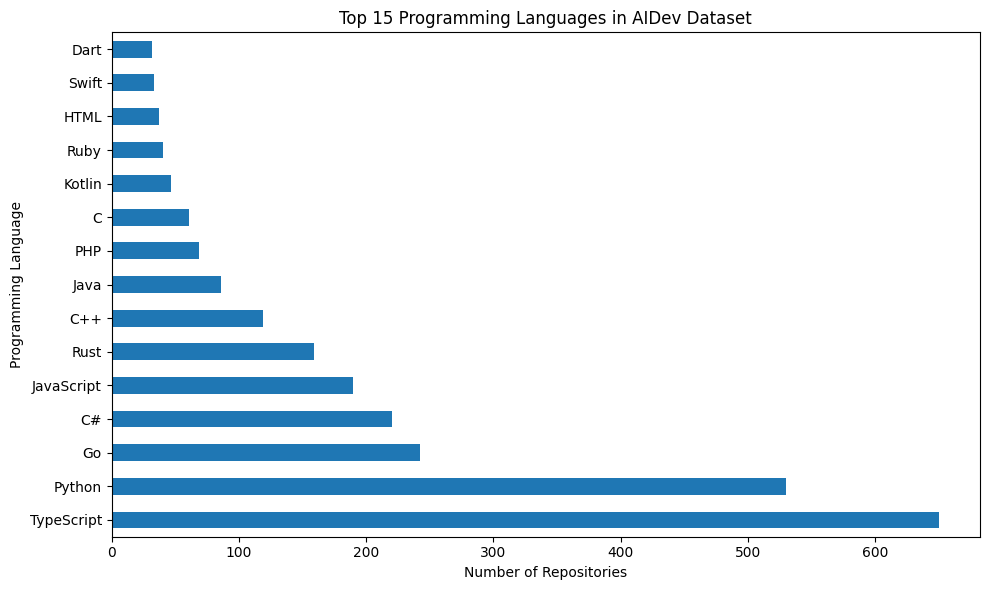

In [3]:
# Count repositories by language
lang_counts = repo_pop_df["language"].value_counts()
print("Top 10 languages by repository count:")
print(lang_counts.head(10))

# Visualize
lang_counts.head(15).plot(kind="barh", figsize=(10, 6))
plt.xlabel("Number of Repositories")
plt.ylabel("Programming Language")
plt.title("Top 15 Programming Languages in AIDev Dataset")
plt.tight_layout()
plt.show()

## Language Distribution by Pull Requests


Top 10 languages by PR count:
language
Go            10108
Python         7191
TypeScript     6503
C#             1985
Java           1278
Rust           1079
JavaScript      987
HTML            755
Ruby            468
C++             422
Name: count, dtype: int64


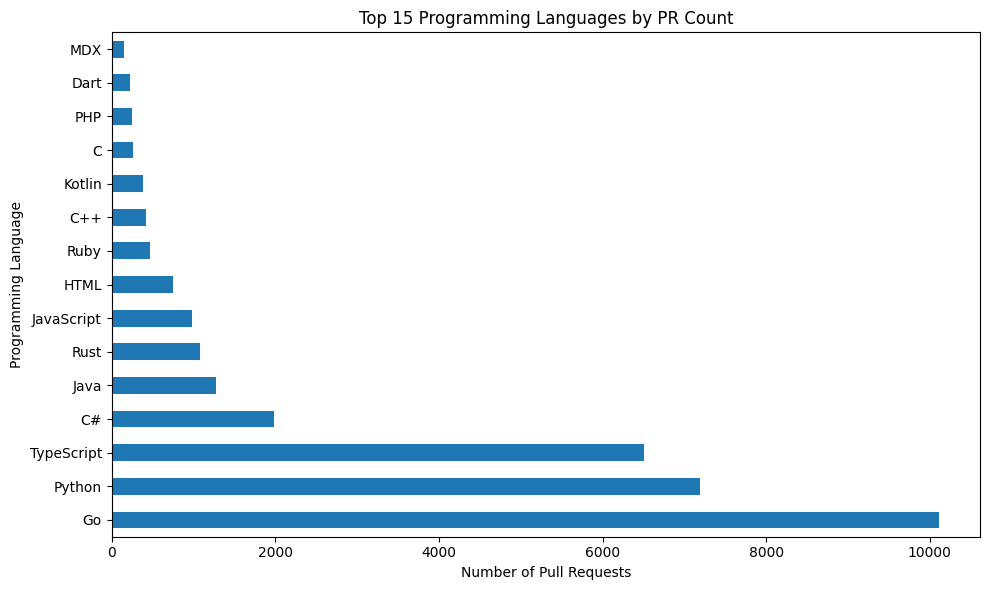

In [4]:
# Merge PRs with repo language
pr_with_lang = pr_pop_df.merge(
    repo_pop_df[["id", "language"]], left_on="repo_id", right_on="id", how="left"
)

# Count PRs by language
pr_lang_counts = pr_with_lang["language"].value_counts()
print("\nTop 10 languages by PR count:")
print(pr_lang_counts.head(10))

# Visualize
pr_lang_counts.head(15).plot(kind="barh", figsize=(10, 6))
plt.xlabel("Number of Pull Requests")
plt.ylabel("Programming Language")
plt.title("Top 15 Programming Languages by PR Count")
plt.tight_layout()
plt.show()

## Agent Distribution by Language

In [5]:
# Get top 3 languages
top_3_langs = pr_lang_counts.head(3).index.tolist()
print(f"\nTop 3 languages for analysis: {top_3_langs}")

# Filter to top 3 languages
top_lang_prs = pr_with_lang[pr_with_lang["language"].isin(top_3_langs)]

# Check agent distribution for each language
print("\nAgent distribution by language:")
for lang in top_3_langs:
    lang_prs = top_lang_prs[top_lang_prs["language"] == lang]
    print(f"\n{lang}: {len(lang_prs):,} PRs")
    if "agent" in lang_prs.columns:
        print(lang_prs["agent"].value_counts())


Top 3 languages for analysis: ['Go', 'Python', 'TypeScript']

Agent distribution by language:

Go: 10,108 PRs
agent
OpenAI_Codex    9509
Copilot          403
Devin             87
Cursor            71
Claude_Code       38
Name: count, dtype: int64

Python: 7,191 PRs
agent
OpenAI_Codex    5209
Devin           1069
Copilot          559
Cursor           254
Claude_Code      100
Name: count, dtype: int64

TypeScript: 6,503 PRs
agent
Devin           2655
OpenAI_Codex    1769
Copilot         1242
Cursor           685
Claude_Code      152
Name: count, dtype: int64


## Summary Statistics

In [6]:
print("\n" + "=" * 60)
print("LANGUAGE ANALYSIS SUMMARY")
print("=" * 60)

for i, lang in enumerate(top_3_langs, 1):
    lang_repos = repo_pop_df[repo_pop_df["language"] == lang]
    lang_prs = top_lang_prs[top_lang_prs["language"] == lang]

    print(f"\n{i}. {lang}")
    print(f"   Repositories: {len(lang_repos):,}")
    print(f"   Pull Requests: {len(lang_prs):,}")
    print(f"   Avg PRs per repo: {len(lang_prs) / len(lang_repos):.1f}")

print(f"\nTotal PRs in top 3 languages: {len(top_lang_prs):,}")
print(f"Percentage of all PRs: {100 * len(top_lang_prs) / len(pr_pop_df):.1f}%")


LANGUAGE ANALYSIS SUMMARY

1. Go
   Repositories: 242
   Pull Requests: 10,108
   Avg PRs per repo: 41.8

2. Python
   Repositories: 530
   Pull Requests: 7,191
   Avg PRs per repo: 13.6

3. TypeScript
   Repositories: 650
   Pull Requests: 6,503
   Avg PRs per repo: 10.0

Total PRs in top 3 languages: 23,802
Percentage of all PRs: 70.8%


In [7]:
# Save the filtered data
top_lang_prs.to_parquet(data_dir / "top3_languages_prs.parquet", index=False)
print(f"\nSaved filtered PRs to: {data_dir / 'top3_languages_prs.parquet'}")


Saved filtered PRs to: ../data/top3_languages_prs.parquet
